In [72]:
#allow output from every line
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
import pandas as pd
import numpy as np
from pybaseball import statcast

In [73]:
import os
from pathlib import Path

os.chdir(Path(r"C:\Users\Newuser\Documents\SAL 603\Final Project"))

In [74]:
start_date = "2025-05-01"
end_date   = "2025-06-28"

df_raw = statcast(start_dt=start_date, end_dt=end_date)
df_raw.to_csv("statcast_raw_2025-05-01_to_2025-06-28.csv", index=False)

print(df_raw.shape)
print(df_raw.head())

This is a large query, it may take a moment to complete


C:\Users\Newuser\AppData\Roaming\Python\Python313\site-packages\pybaseball\statcast.py:50: UserWarning: 
That's a nice request you got there. It'd be a shame if something were to happen to it.
We strongly recommend that you enable caching before running this. It's as simple as `pybaseball.cache.enable()`.
Since the Statcast requests can take a *really* long time to run, if something were to happen, like: a disconnect;
gremlins; computer repair by associates of Rudy Giuliani; electromagnetic interference from metal trash cans; etc.;
you could lose a lot of progress. Enabling caching will allow you to immediately recover all the successful
subqueries if that happens.
  warnings.warn(_OVERSIZE_WARNING)
  0%|          | 0/59 [00:00<?, ?it/s]C:\Users\Newuser\AppData\Roaming\Python\Python313\site-packages\pybaseball\datahelpers\postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions e

(229216, 118)
     pitch_type  game_date  release_speed  release_pos_x  release_pos_z  \
2567         SI 2025-06-28           94.9          -1.72           5.22   
2684         FF 2025-06-28           95.5          -1.55           5.27   
2777         FS 2025-06-28           88.3          -1.51           5.06   
2875         FS 2025-06-28           87.8          -1.46           5.14   
2969         SI 2025-06-28           94.7          -1.59           5.36   

          player_name  batter  pitcher     events    description  ...  \
2567  Montero, Rafael  592663   606160  field_out  hit_into_play  ...   
2684  Montero, Rafael  592663   606160        NaN           foul  ...   
2777  Montero, Rafael  592663   606160        NaN           foul  ...   
2875  Montero, Rafael  592663   606160        NaN           foul  ...   
2969  Montero, Rafael  592663   606160        NaN           foul  ...   

      batter_days_until_next_game  api_break_z_with_gravity  api_break_x_arm  \
2567            

In [75]:
keep_cols = [
    "game_date",
    "game_pk",
    "at_bat_number",
    "pitch_number",
    "batter",
    "pitcher",
    "player_name",
    "pitch_type",
    "pitch_name",
    "release_speed",
    "release_spin_rate",   
    "release_extension",
    "pfx_x",
    "pfx_z",
    "plate_x",
    "plate_z",
    "sz_top",
    "sz_bot",
    "stand",
    "p_throws",
    "balls",
    "strikes",
    "outs_when_up",
    "inning",
    "inning_topbot",
    "description",
    "type",
    "events",
    "launch_speed",
    "launch_angle",
    "estimated_woba_using_speedangle",
    "woba_value",
    "delta_run_exp"
]

existing_cols = [c for c in keep_cols if c in df_raw.columns]
df = df_raw[existing_cols].copy()

print(df.shape)
print(df.columns.tolist())

(229216, 33)
['game_date', 'game_pk', 'at_bat_number', 'pitch_number', 'batter', 'pitcher', 'player_name', 'pitch_type', 'pitch_name', 'release_speed', 'release_spin_rate', 'release_extension', 'pfx_x', 'pfx_z', 'plate_x', 'plate_z', 'sz_top', 'sz_bot', 'stand', 'p_throws', 'balls', 'strikes', 'outs_when_up', 'inning', 'inning_topbot', 'description', 'type', 'events', 'launch_speed', 'launch_angle', 'estimated_woba_using_speedangle', 'woba_value', 'delta_run_exp']


In [76]:
# standardize column types
df["game_date"] = pd.to_datetime(df["game_date"], errors="coerce")

numeric_cols = [
    "release_speed", "release_spin_rate", "release_extension",
    "pfx_x", "pfx_z", "plate_x", "plate_z",
    "sz_top", "sz_bot", "balls", "strikes",
    "outs_when_up", "inning", "pitch_number", "at_bat_number",
    "launch_speed", "launch_angle", "estimated_woba_using_speedangle",
    "woba_value", "delta_run_exp"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# drop duplicates if any
df = df.drop_duplicates(subset=["game_pk", "at_bat_number", "pitch_number"]).copy()

print(df.isna().mean().sort_values(ascending=False).head(15))

estimated_woba_using_speedangle    0.744106
woba_value                         0.741240
events                             0.741240
launch_speed                       0.666611
launch_angle                       0.666014
release_spin_rate                  0.005301
release_extension                  0.003512
plate_x                            0.003464
pitch_type                         0.003464
pitch_name                         0.003464
plate_z                            0.003464
delta_run_exp                      0.003460
sz_bot                             0.003403
sz_top                             0.003403
pfx_z                              0.003403
dtype: float64


In [77]:
print(df["description"].value_counts(dropna=False).head(25))
print(df["type"].value_counts(dropna=False))
print(df["events"].value_counts(dropna=False).head(25))

description
ball                       76441
foul                       41082
hit_into_play              40749
called_strike              37262
swinging_strike            23338
blocked_ball                4764
foul_tip                    2372
swinging_strike_blocked     1271
automatic_ball               758
hit_by_pitch                 638
foul_bunt                    417
missed_bunt                   65
automatic_strike              35
pitchout                      15
bunt_foul_tip                  9
Name: count, dtype: int64
type
S    105858
B     82616
X     40742
Name: count, dtype: int64
events
NaN                          169904
field_out                     24258
strikeout                     12859
single                         8678
walk                           4706
double                         2464
home_run                       1780
grounded_into_double_play      1047
force_out                      1041
hit_by_pitch                    638
sac_fly                         4

In [78]:
zone_cols = ["plate_x", "plate_z", "sz_bot", "sz_top"]

for col in zone_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

zone_mask = (
    df["plate_x"].between(-0.83, 0.83, inclusive="both") &
    df["plate_z"].ge(df["sz_bot"]) &
    df["plate_z"].le(df["sz_top"])
).fillna(False)

df["in_zone"] = zone_mask.astype(int)

In [79]:
swing_descriptions = {
    "swinging_strike",
    "swinging_strike_blocked",
    "foul",
    "foul_tip",
    "foul_bunt",
    "bunt_foul_tip",
    "missed_bunt",
    "hit_into_play",
    "hit_into_play_no_out",
    "hit_into_play_score"
}

take_descriptions = {
    "ball",
    "blocked_ball",
    "called_strike",
    "pitchout",
    "automatic_ball",
    "automatic_strike",
    "hit_by_pitch"
}

whiff_descriptions = {
    "swinging_strike",
    "swinging_strike_blocked",
    "missed_bunt"
}

called_strike_descriptions = {
    "called_strike",
    "automatic_strike"
}

ball_descriptions = {
    "ball",
    "blocked_ball",
    "pitchout",
    "automatic_ball",
    "hit_by_pitch"
}

in_play_descriptions = {
    "hit_into_play",
    "hit_into_play_no_out",
    "hit_into_play_score"
}

contact_descriptions = {
    "foul",
    "foul_tip",
    "foul_bunt",
    "bunt_foul_tip",
    "hit_into_play",
    "hit_into_play_no_out",
    "hit_into_play_score"
}

df["description"] = df["description"].astype(str)

df["did_swing"] = df["description"].isin(swing_descriptions).astype(int)
df["did_take"] = df["description"].isin(take_descriptions).astype(int)
df["is_whiff"] = df["description"].isin(whiff_descriptions).astype(int)
df["is_called_strike"] = df["description"].isin(called_strike_descriptions).astype(int)
df["is_ball"] = df["description"].isin(ball_descriptions).astype(int)
df["is_in_play"] = df["description"].isin(in_play_descriptions).astype(int)
df["made_contact"] = df["description"].isin(contact_descriptions).astype(int)
df["zone_swing"] = np.where((df["in_zone"] == 1) & (df["did_swing"] == 1), 1, 0)
df["zone_take"] = np.where((df["in_zone"] == 1) & (df["did_take"] == 1), 1, 0)
df["chase"] = np.where((df["in_zone"] == 0) & (df["did_swing"] == 1), 1, 0)
df["take_ball"] = np.where((df["in_zone"] == 0) & (df["did_take"] == 1), 1, 0)

In [80]:
print(df["in_zone"].value_counts(dropna=False))

in_zone
0    122086
1    107130
Name: count, dtype: int64


In [81]:
conditions = [
    df["description"].eq("hit_by_pitch"),
    df["is_whiff"] == 1,
    df["is_in_play"] == 1,
    (df["made_contact"] == 1) & (df["is_in_play"] == 0),
    df["is_called_strike"] == 1,
    df["is_ball"] == 1
]

choices = [
    "hit_by_pitch",
    "whiff",
    "in_play",
    "foul_or_other_contact",
    "called_strike",
    "ball"
]

df["pitch_outcome_group"] = np.select(conditions, choices, default="other")
print(df["pitch_outcome_group"].value_counts(dropna=False))

pitch_outcome_group
ball                     81978
foul_or_other_contact    43880
in_play                  40749
called_strike            37297
whiff                    24674
hit_by_pitch               638
Name: count, dtype: int64


In [82]:
print("Total rows:", len(df))
print("Swing rate:", df["did_swing"].mean())
print("Take rate:", df["did_take"].mean())
print("Whiff rate:", df["is_whiff"].mean())
print("In-play rate:", df["is_in_play"].mean())

# Should be mostly one or the other
print(df[["did_swing", "did_take"]].sum(axis=1).value_counts(dropna=False))

# Sample suspicious rows
suspicious = df[df[["did_swing", "did_take"]].sum(axis=1) == 0][
    ["description", "type", "events"]
]
print(suspicious.value_counts().head(20))

Total rows: 229216
Swing rate: 0.47685589138629064
Take rate: 0.5231441086137093
Whiff rate: 0.10764519056261343
In-play rate: 0.17777554795476755
1    229216
Name: count, dtype: int64
Series([], Name: count, dtype: int64)


In [83]:
print("Total pitches:", len(df))
print("Swing rate:", round(df["did_swing"].mean(), 4))
print("Take rate:", round(df["did_take"].mean(), 4))
print("Zone rate:", round(df["in_zone"].mean(), 4))
print("Zone swing rate:", round(df["zone_swing"].sum() / max((df["in_zone"] == 1).sum(), 1), 4))
print("Chase rate:", round(df["chase"].sum() / max((df["in_zone"] == 0).sum(), 1), 4))
print("Whiff rate on swings:", round(df["is_whiff"].sum() / max(df["did_swing"].sum(), 1), 4))

Total pitches: 229216
Swing rate: 0.4769
Take rate: 0.5231
Zone rate: 0.4674
Zone swing rate: 0.6776
Chase rate: 0.3007
Whiff rate on swings: 0.2257


In [84]:
df.to_csv("statcast_clean_labeled_2025-05-01_to_2025-06-28.csv", index=False)

In [85]:
DATA_DIR = r"C:\Users\Newuser\Documents\SAL 603\Final Project"
df = pd.read_csv("statcast_clean_labeled_2025-05-01_to_2025-06-28.csv")
print(df.shape)
print(df.head())

(229216, 46)
    game_date  game_pk  at_bat_number  pitch_number  batter  pitcher  \
0  2025-06-28   777333             71            11  592663   606160   
1  2025-06-28   777333             71            10  592663   606160   
2  2025-06-28   777333             71             9  592663   606160   
3  2025-06-28   777333             71             8  592663   606160   
4  2025-06-28   777333             71             7  592663   606160   

       player_name pitch_type       pitch_name  release_speed  ...  is_whiff  \
0  Montero, Rafael         SI           Sinker           94.9  ...         0   
1  Montero, Rafael         FF  4-Seam Fastball           95.5  ...         0   
2  Montero, Rafael         FS     Split-Finger           88.3  ...         0   
3  Montero, Rafael         FS     Split-Finger           87.8  ...         0   
4  Montero, Rafael         SI           Sinker           94.7  ...         0   

   is_called_strike  is_ball  is_in_play  made_contact  zone_swing  zone_

In [86]:
exclude_descriptions = {"pitchout", "automatic_ball", "automatic_strike","hit_by_pitch"}

model_df = df[~df["description"].isin(exclude_descriptions)].copy()

print(model_df.shape)
print(model_df["description"].value_counts(dropna=False).head(20))

(227770, 46)
description
ball                       76441
foul                       41082
hit_into_play              40749
called_strike              37262
swinging_strike            23338
blocked_ball                4764
foul_tip                    2372
swinging_strike_blocked     1271
foul_bunt                    417
missed_bunt                   65
bunt_foul_tip                  9
Name: count, dtype: int64


In [87]:
target = "did_swing"

numeric_features = [
    "plate_x",
    "plate_z",
    "balls",
    "strikes",
    "release_speed",
    "pfx_x",
    "pfx_z",
    "sz_top",
    "sz_bot"
]

categorical_features = [
    "pitch_type",
    "stand",
    "p_throws",
    "inning_topbot"
]

feature_cols = numeric_features + categorical_features

model_df = model_df[[target] + feature_cols].dropna().copy()

X = model_df[feature_cols]
y = model_df[target]

print(X.shape, y.shape)
print(y.value_counts(normalize=True))

(227767, 13) (227767,)
did_swing
0    0.520115
1    0.479885
Name: proportion, dtype: float64


In [88]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())

(182213, 13) (45554, 13)
0.4798834331249691 0.4798919963120692


In [89]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

logit_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

logit_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [90]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

logit_probs = logit_model.predict_proba(X_test)[:, 1]
logit_preds = logit_model.predict(X_test)

print("Logistic Regression ROC AUC:", roc_auc_score(y_test, logit_probs))
print(classification_report(y_test, logit_preds))
print(confusion_matrix(y_test, logit_preds))


Logistic Regression ROC AUC: 0.638991447004271
              precision    recall  f1-score   support

           0       0.61      0.67      0.64     23693
           1       0.60      0.53      0.56     21861

    accuracy                           0.60     45554
   macro avg       0.60      0.60      0.60     45554
weighted avg       0.60      0.60      0.60     45554

[[15940  7753]
 [10292 11569]]


In [91]:
from sklearn.ensemble import HistGradientBoostingClassifier

#  preprocessor separately
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

hgb_model = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

hgb_model.fit(X_train_processed, y_train)

hgb_probs = hgb_model.predict_proba(X_test_processed)[:, 1]
hgb_preds = hgb_model.predict(X_test_processed)

print("HistGradientBoosting ROC AUC:", roc_auc_score(y_test, hgb_probs))
print(classification_report(y_test, hgb_preds))
print(confusion_matrix(y_test, hgb_preds))

,loss,'log_loss'
,learning_rate,0.05
,max_iter,200
,max_leaf_nodes,31
,max_depth,6
,min_samples_leaf,20
,l2_regularization,0.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'
,monotonic_cst,None


HistGradientBoosting ROC AUC: 0.8850440887675466
              precision    recall  f1-score   support

           0       0.82      0.78      0.80     23693
           1       0.78      0.81      0.79     21861

    accuracy                           0.80     45554
   macro avg       0.80      0.80      0.80     45554
weighted avg       0.80      0.80      0.80     45554

[[18551  5142]
 [ 4091 17770]]


In [92]:
results = pd.DataFrame({
    "model": ["Logistic Regression", "HistGradientBoosting"],
    "roc_auc": [
        roc_auc_score(y_test, logit_probs),
        roc_auc_score(y_test, hgb_probs)
    ]
})

print(results)

                  model   roc_auc
0   Logistic Regression  0.638991
1  HistGradientBoosting  0.885044


In [93]:
test_results = X_test.copy()
test_results["actual_did_swing"] = y_test.values
test_results["pred_swing_prob_logit"] = logit_probs
test_results["pred_swing_prob_hgb"] = hgb_probs
test_results["pred_swing_class_hgb"] = hgb_preds

test_results.to_csv("week2_test_predictions.csv", index=False)
print(test_results.head())

         plate_x   plate_z  balls  strikes  release_speed  pfx_x  pfx_z  \
209146 -0.616350  4.992223      1        2           97.6   0.59   1.38   
219196  0.115363  2.270693      3        2           96.9   1.48   0.73   
55465  -0.606249  1.440284      1        2           89.9  -1.30   0.60   
173712 -0.505666  1.641259      0        1           88.1  -1.22   0.02   
125491 -0.883019  3.188380      2        1           92.3  -1.32   0.18   

        sz_top  sz_bot pitch_type stand p_throws inning_topbot  \
209146    3.56    1.77         FF     R        L           Bot   
219196    3.87    1.81         SI     L        L           Bot   
55465     3.72    1.78         FS     L        R           Top   
173712    3.44    1.61         FS     L        R           Bot   
125491    3.66    1.70         SI     R        R           Bot   

        actual_did_swing  pred_swing_prob_logit  pred_swing_prob_hgb  \
209146                 0               0.719292             0.019280   
219196  

In [94]:
test_results["prob_bin"] = pd.cut(
    test_results["pred_swing_prob_hgb"],
    bins=np.linspace(0, 1, 11),
    include_lowest=True
)

calibration_check = test_results.groupby("prob_bin", observed=False).agg(
    avg_pred_prob=("pred_swing_prob_hgb", "mean"),
    actual_swing_rate=("actual_did_swing", "mean"),
    n=("actual_did_swing", "size")
).reset_index()

print(calibration_check)

        prob_bin  avg_pred_prob  actual_swing_rate     n
0  (-0.001, 0.1]       0.044270           0.018773  7564
1     (0.1, 0.2]       0.148007           0.107460  4504
2     (0.2, 0.3]       0.248237           0.225083  3612
3     (0.3, 0.4]       0.350518           0.320165  3392
4     (0.4, 0.5]       0.451214           0.438655  3570
5     (0.5, 0.6]       0.550527           0.550497  4327
6     (0.6, 0.7]       0.649244           0.677447  4731
7     (0.7, 0.8]       0.751251           0.776919  4272
8     (0.8, 0.9]       0.852827           0.895003  5543
9     (0.9, 1.0]       0.936558           0.966328  4039


In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

In [96]:
print("Current working directory:", os.getcwd())

file_path = r"C:\Users\Newuser\Documents\SAL 603\Final Project\week2_test_predictions.csv"
test_results = pd.read_csv(file_path)

print("Shape:", test_results.shape)
print("\nColumns:")
print(test_results.columns.tolist())

Current working directory: C:\Users\Newuser\Documents\SAL 603\Final Project
Shape: (45554, 17)

Columns:
['plate_x', 'plate_z', 'balls', 'strikes', 'release_speed', 'pfx_x', 'pfx_z', 'sz_top', 'sz_bot', 'pitch_type', 'stand', 'p_throws', 'inning_topbot', 'actual_did_swing', 'pred_swing_prob_logit', 'pred_swing_prob_hgb', 'pred_swing_class_hgb']


In [97]:
required_cols = ["plate_x", "plate_z", "actual_did_swing", "pred_swing_prob_hgb"]
missing_cols = [col for col in required_cols if col not in test_results.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

# Ensure numeric columns are numeric
for col in ["plate_x", "plate_z", "actual_did_swing", "pred_swing_prob_hgb"]:
    test_results[col] = pd.to_numeric(test_results[col], errors="coerce")

# Drop rows missing key values
test_results = test_results.dropna(subset=required_cols).copy()

print("\nShape after dropping missing key fields:", test_results.shape)


Shape after dropping missing key fields: (45554, 17)


In [98]:
# Adjust for tighter or wider view
x_bins = np.linspace(-2, 2, 21)   # 20 bins across
z_bins = np.linspace(0, 5, 21)    # 20 bins vertically

test_results["x_bin"] = pd.cut(
    test_results["plate_x"],
    bins=x_bins,
    include_lowest=True
)

test_results["z_bin"] = pd.cut(
    test_results["plate_z"],
    bins=z_bins,
    include_lowest=True
)

# Drop rows outside the bin ranges
test_results = test_results.dropna(subset=["x_bin", "z_bin"]).copy()

print("\nShape after binning:", test_results.shape)


Shape after binning: (44323, 19)


In [99]:
def build_heatmaps(df, pred_col="pred_swing_prob_hgb", min_pitches=25):
    """
    Builds zone-level summary tables and pivoted heatmaps.
    Returns:
        zone_summary, actual_heatmap, pred_heatmap, diff_heatmap, count_heatmap
    """
    
    zone_summary = (
        df.groupby(["z_bin", "x_bin"], observed=False)
          .agg(
              actual_swing_rate=("actual_did_swing", "mean"),
              pred_swing_prob=(pred_col, "mean"),
              pitch_count=("actual_did_swing", "size")
          )
          .reset_index()
    )
    
    zone_summary["swing_diff"] = (
        zone_summary["actual_swing_rate"] - zone_summary["pred_swing_prob"]
    )
    
    actual_heatmap = zone_summary.pivot_table(
        index="z_bin",
        columns="x_bin",
        values="actual_swing_rate"
    )
    
    pred_heatmap = zone_summary.pivot_table(
        index="z_bin",
        columns="x_bin",
        values="pred_swing_prob"
    )
    
    diff_heatmap = zone_summary.pivot_table(
        index="z_bin",
        columns="x_bin",
        values="swing_diff"
    )
    
    count_heatmap = zone_summary.pivot_table(
        index="z_bin",
        columns="x_bin",
        values="pitch_count"
    )
    
    # Flip rows so high pitches appear at the top
    actual_heatmap = actual_heatmap.iloc[::-1]
    pred_heatmap = pred_heatmap.iloc[::-1]
    diff_heatmap = diff_heatmap.iloc[::-1]
    count_heatmap = count_heatmap.iloc[::-1]
    
    # Mask sparse cells
    actual_heatmap = actual_heatmap.where(count_heatmap >= min_pitches)
    pred_heatmap = pred_heatmap.where(count_heatmap >= min_pitches)
    diff_heatmap = diff_heatmap.where(count_heatmap >= min_pitches)
    
    return zone_summary, actual_heatmap, pred_heatmap, diff_heatmap, count_heatmap


In [100]:
def plot_heatmaps(actual_heatmap, pred_heatmap, diff_heatmap, title_prefix="Overall"):
    fig, axes = plt.subplots(1, 3, figsize=(22, 7))
    
    sns.heatmap(
        actual_heatmap,
        cmap="Blues",
        linewidths=0.3,
        cbar_kws={"label": "Actual swing rate"},
        ax=axes[0]
    )
    axes[0].set_title(f"{title_prefix}: actual swing rate")
    axes[0].set_xlabel("Plate X bin")
    axes[0].set_ylabel("Plate Z bin")
    
    sns.heatmap(
        pred_heatmap,
        cmap="Greens",
        linewidths=0.3,
        cbar_kws={"label": "Predicted swing probability"},
        ax=axes[1]
    )
    axes[1].set_title(f"{title_prefix}: predicted swing probability")
    axes[1].set_xlabel("Plate X bin")
    axes[1].set_ylabel("")
    
    sns.heatmap(
        diff_heatmap,
        cmap="coolwarm",
        center=0,
        linewidths=0.3,
        cbar_kws={"label": "Actual - predicted"},
        ax=axes[2]
    )
    axes[2].set_title(f"{title_prefix}: difference map")
    axes[2].set_xlabel("Plate X bin")
    axes[2].set_ylabel("")
    
    plt.tight_layout()
    plt.show()



Zone summary preview:
            z_bin           x_bin  actual_swing_rate  pred_swing_prob  \
0  (-0.001, 0.25]  (-2.001, -1.8]                0.0         0.024731   
1  (-0.001, 0.25]    (-1.8, -1.6]                0.0         0.059444   
2  (-0.001, 0.25]    (-1.6, -1.4]                0.0         0.039032   
3  (-0.001, 0.25]    (-1.4, -1.2]                0.0         0.073782   
4  (-0.001, 0.25]    (-1.2, -1.0]                0.0         0.074060   

   pitch_count  swing_diff  
0            1   -0.024731  
1            2   -0.059444  
2            8   -0.039032  
3           11   -0.073782  
4            8   -0.074060  

Zone summary stats:
       actual_swing_rate  pred_swing_prob  swing_diff  pitch_count
count         398.000000       398.000000  398.000000   400.000000
mean            0.247183         0.254443   -0.007260   110.807500
std             0.234475         0.224172    0.044893   125.011179
min             0.000000         0.001203   -0.127124     0.000000
25%     

C:\Users\Newuser\AppData\Local\Temp\ipykernel_22364\271068064.py:22: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  actual_heatmap = zone_summary.pivot_table(
C:\Users\Newuser\AppData\Local\Temp\ipykernel_22364\271068064.py:28: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pred_heatmap = zone_summary.pivot_table(
C:\Users\Newuser\AppData\Local\Temp\ipykernel_22364\271068064.py:34: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  diff_heatmap = zone_summary.pivot_table(
C:\Users\Newuser\AppData\Local\Temp\ip

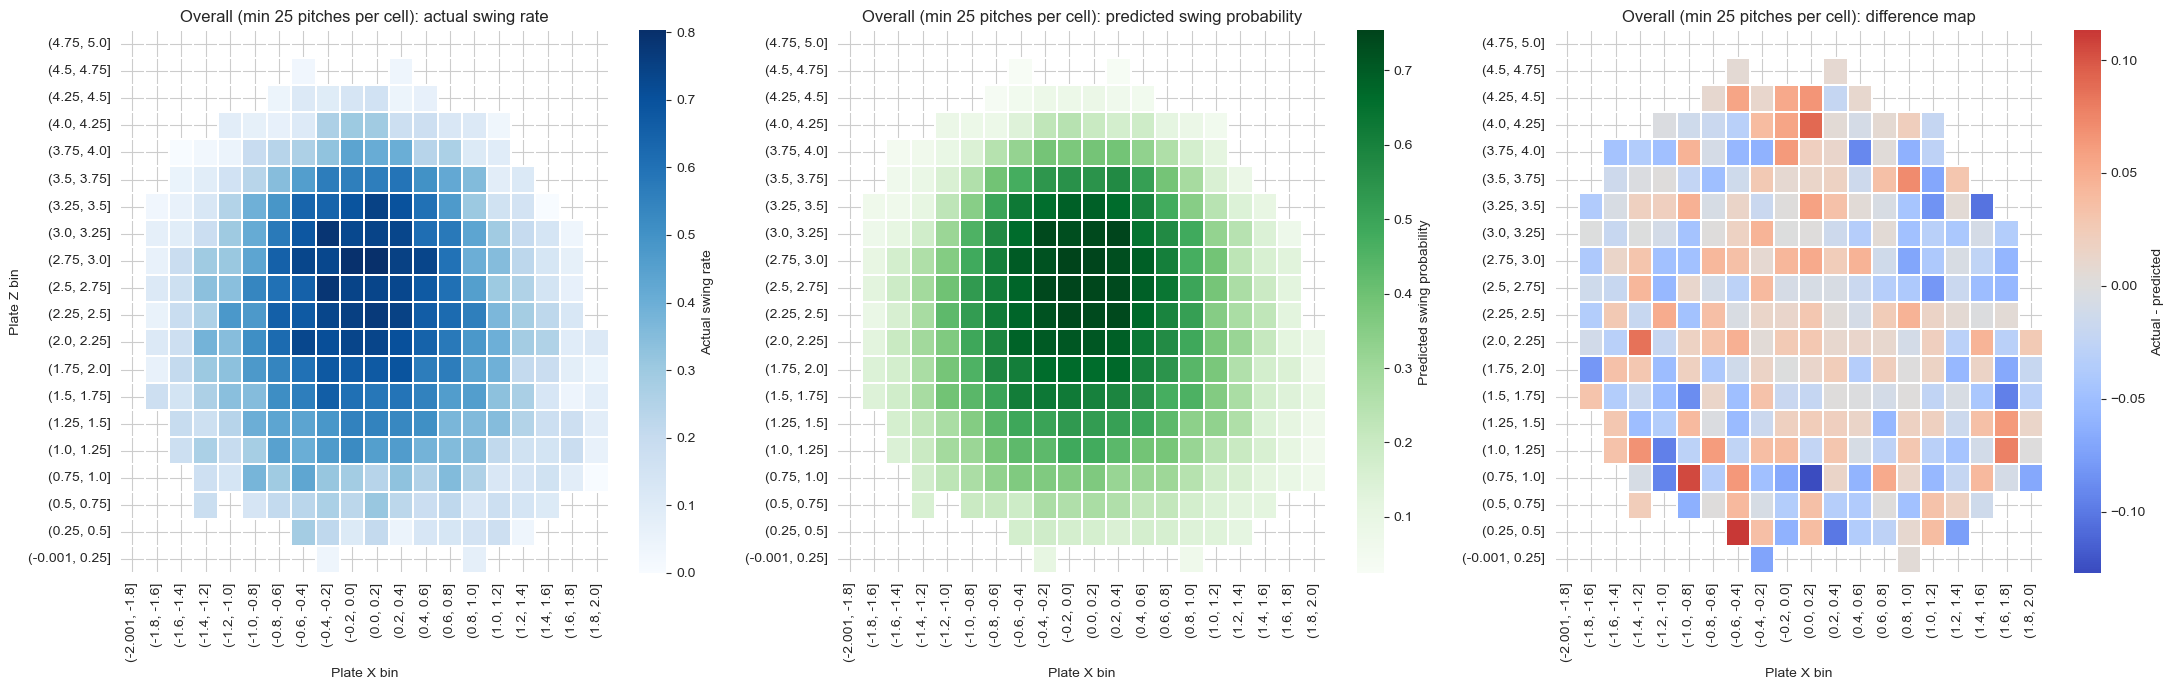

In [101]:
min_pitches = 25

zone_summary, actual_heatmap, pred_heatmap, diff_heatmap, count_heatmap = build_heatmaps(
    test_results,
    pred_col="pred_swing_prob_hgb",
    min_pitches=min_pitches
)

print("\nZone summary preview:")
print(zone_summary.head())

print("\nZone summary stats:")
print(zone_summary[["actual_swing_rate", "pred_swing_prob", "swing_diff", "pitch_count"]].describe())

plot_heatmaps(
    actual_heatmap,
    pred_heatmap,
    diff_heatmap,
    title_prefix=f"Overall (min {min_pitches} pitches per cell)"
)


In [102]:
def save_single_heatmap(data, title, cbar_label, filename, cmap="Blues", center=None, dpi=300):
    fig, ax = plt.subplots(figsize=(8, 7))
    sns.heatmap(
        data,
        cmap=cmap,
        center=center,
        linewidths=0.3,
        cbar_kws={"label": cbar_label},
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel("Plate X bin")
    ax.set_ylabel("Plate Z bin")

    plt.tight_layout()

    # Print where it will save (helps debug working directory issues)
    out_path = os.path.abspath(filename)
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight")
    plt.close(fig)

    print(f"Saved: {out_path}")

In [103]:
save_single_heatmap(
    actual_heatmap,
    title=f"Actual swing rate (min {min_pitches} pitches/cell)",
    cbar_label="Actual swing rate",
    filename="final_actual_min.png",
    cmap="Blues"
)

save_single_heatmap(
    pred_heatmap,
    title=f"Predicted swing probability (min {min_pitches} pitches/cell)",
    cbar_label="Predicted swing probability",
    filename="final_pred_min.png",
    cmap="Greens"
)

save_single_heatmap(
    diff_heatmap,
    title=f"Difference: actual - predicted (min {min_pitches} pitches/cell)",
    cbar_label="Actual - predicted",
    filename="final_diff_min.png",
    cmap="coolwarm",
    center=0
)

Saved: C:\Users\Newuser\Documents\SAL 603\Final Project\final_actual_min.png
Saved: C:\Users\Newuser\Documents\SAL 603\Final Project\final_pred_min.png
Saved: C:\Users\Newuser\Documents\SAL 603\Final Project\final_diff_min.png


In [104]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

sns.set_style("whitegrid")

In [105]:
df = pd.read_csv("statcast_clean_labeled_2025-05-01_to_2025-06-28.csv")

print("Cleaned data shape:", df.shape)
print(df.head())

# Make sure key numeric columns are numeric
numeric_cols = [
    "plate_x", "plate_z", "balls", "strikes", "release_speed",
    "pfx_x", "pfx_z", "sz_top", "sz_bot"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

Cleaned data shape: (229216, 46)
    game_date  game_pk  at_bat_number  pitch_number  batter  pitcher  \
0  2025-06-28   777333             71            11  592663   606160   
1  2025-06-28   777333             71            10  592663   606160   
2  2025-06-28   777333             71             9  592663   606160   
3  2025-06-28   777333             71             8  592663   606160   
4  2025-06-28   777333             71             7  592663   606160   

       player_name pitch_type       pitch_name  release_speed  ...  is_whiff  \
0  Montero, Rafael         SI           Sinker           94.9  ...         0   
1  Montero, Rafael         FF  4-Seam Fastball           95.5  ...         0   
2  Montero, Rafael         FS     Split-Finger           88.3  ...         0   
3  Montero, Rafael         FS     Split-Finger           87.8  ...         0   
4  Montero, Rafael         SI           Sinker           94.7  ...         0   

   is_called_strike  is_ball  is_in_play  made_contac

In [106]:
skubal_name = "Skubal, Tarik"

In [107]:
exclude_descriptions = {"pitchout", "automatic_ball", "automatic_strike", "hit_by_pitch"}

target = "did_swing"

numeric_features = [
    "plate_x",
    "plate_z",
    "balls",
    "strikes",
    "release_speed",
    "pfx_x",
    "pfx_z",
    "sz_top",
    "sz_bot"
]

categorical_features = [
    "pitch_type",
    "stand",
    "p_throws",
    "inning_topbot"
]

id_cols = [
    "game_date",
    "game_pk",
    "at_bat_number",
    "pitch_number",
    "batter",
    "pitcher",
    "player_name",
    "pitch_type",
    "stand",
    "p_throws",
    "description",
    "events",
    "plate_x",
    "plate_z",
    "balls",
    "strikes"
]

feature_cols = numeric_features + categorical_features

model_df = df[~df["description"].isin(exclude_descriptions)].copy()

# Keep all needed columns together before dropping missing values
model_keep_cols = list(dict.fromkeys(id_cols + [target] + feature_cols))
model_df = model_df[model_keep_cols].dropna(subset=feature_cols + [target]).copy()

print("\nModeling dataframe shape:", model_df.shape)

X = model_df[feature_cols].copy()
y = model_df[target].copy()

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X,
    y,
    model_df.index,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Model
hgb_model = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

hgb_model.fit(X_train_processed, y_train)

hgb_probs = hgb_model.predict_proba(X_test_processed)[:, 1]
hgb_preds = hgb_model.predict(X_test_processed)

print("\nWeek 4 rebuilt model check")
print("ROC AUC:", roc_auc_score(y_test, hgb_probs))
print(classification_report(y_test, hgb_preds))
print(confusion_matrix(y_test, hgb_preds))

# Build enriched test results
test_results = model_df.loc[idx_test, id_cols].copy()
test_results["actual_did_swing"] = y_test.values
test_results["pred_swing_prob_hgb"] = hgb_probs
test_results["pred_swing_class_hgb"] = hgb_preds

test_results.to_csv("week4_test_predictions_enriched.csv", index=False)
print("\nSaved: week4_test_predictions_enriched.csv")
print(test_results.head())


Modeling dataframe shape: (227767, 23)


,loss,'log_loss'
,learning_rate,0.05
,max_iter,200
,max_leaf_nodes,31
,max_depth,6
,min_samples_leaf,20
,l2_regularization,0.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'
,monotonic_cst,None



Week 4 rebuilt model check
ROC AUC: 0.8850440887675466
              precision    recall  f1-score   support

           0       0.82      0.78      0.80     23693
           1       0.78      0.81      0.79     21861

    accuracy                           0.80     45554
   macro avg       0.80      0.80      0.80     45554
weighted avg       0.80      0.80      0.80     45554

[[18551  5142]
 [ 4091 17770]]

Saved: week4_test_predictions_enriched.csv
         game_date  game_pk  at_bat_number  pitch_number  batter  pitcher  \
209146  2025-05-06   778027             85             4  621020   669062   
219196  2025-05-03   778074             63             6  641355   664076   
55465   2025-06-14   777518             67             4  666139   592773   
173712  2025-05-14   777938             78             2  702616   663485   
125491  2025-05-27   777749             28             4  668901   686563   

                player_name pitch_type stand p_throws    description  \
209146 

In [108]:
def add_zone_bins(input_df, x_min=-2, x_max=2, z_min=0, z_max=5, n_bins=20):
    df2 = input_df.copy()
    x_bins = np.linspace(x_min, x_max, n_bins + 1)
    z_bins = np.linspace(z_min, z_max, n_bins + 1)

    df2["x_bin"] = pd.cut(df2["plate_x"], bins=x_bins, include_lowest=True)
    df2["z_bin"] = pd.cut(df2["plate_z"], bins=z_bins, include_lowest=True)

    return df2.dropna(subset=["x_bin", "z_bin"]).copy()

def build_heatmaps(input_df, pred_col="pred_swing_prob_hgb", min_pitches=5):
    zone_summary = (
        input_df.groupby(["z_bin", "x_bin"], observed=False)
        .agg(
            actual_swing_rate=("actual_did_swing", "mean"),
            pred_swing_prob=(pred_col, "mean"),
            pitch_count=("actual_did_swing", "size")
        )
        .reset_index()
    )

    zone_summary["swing_diff"] = (
        zone_summary["actual_swing_rate"] - zone_summary["pred_swing_prob"]
    )

    actual_heatmap = zone_summary.pivot_table(index="z_bin", columns="x_bin", values="actual_swing_rate")
    pred_heatmap = zone_summary.pivot_table(index="z_bin", columns="x_bin", values="pred_swing_prob")
    diff_heatmap = zone_summary.pivot_table(index="z_bin", columns="x_bin", values="swing_diff")
    count_heatmap = zone_summary.pivot_table(index="z_bin", columns="x_bin", values="pitch_count")

    actual_heatmap = actual_heatmap.iloc[::-1]
    pred_heatmap = pred_heatmap.iloc[::-1]
    diff_heatmap = diff_heatmap.iloc[::-1]
    count_heatmap = count_heatmap.iloc[::-1]

    actual_heatmap = actual_heatmap.where(count_heatmap >= min_pitches)
    pred_heatmap = pred_heatmap.where(count_heatmap >= min_pitches)
    diff_heatmap = diff_heatmap.where(count_heatmap >= min_pitches)

    return zone_summary, actual_heatmap, pred_heatmap, diff_heatmap, count_heatmap

def plot_three_heatmaps(actual_heatmap, pred_heatmap, diff_heatmap, title_prefix="Hitter"):
    fig, axes = plt.subplots(1, 3, figsize=(22, 7))

    sns.heatmap(
        actual_heatmap,
        cmap="Blues",
        linewidths=0.3,
        cbar_kws={"label": "Actual swing rate"},
        ax=axes[0]
    )
    axes[0].set_title(f"{title_prefix}: actual swing rate")
    axes[0].set_xlabel("Plate X bin")
    axes[0].set_ylabel("Plate Z bin")

    sns.heatmap(
        pred_heatmap,
        cmap="Greens",
        linewidths=0.3,
        cbar_kws={"label": "Predicted swing probability"},
        ax=axes[1]
    )
    axes[1].set_title(f"{title_prefix}: predicted swing probability")
    axes[1].set_xlabel("Plate X bin")
    axes[1].set_ylabel("")

    sns.heatmap(
        diff_heatmap,
        cmap="coolwarm",
        center=0,
        linewidths=0.3,
        cbar_kws={"label": "Actual - predicted"},
        ax=axes[2]
    )
    axes[2].set_title(f"{title_prefix}: difference map")
    axes[2].set_xlabel("Plate X bin")
    axes[2].set_ylabel("")

    plt.tight_layout()
    plt.show()

def classify_count_bucket(row):
    balls = row["balls"]
    strikes = row["strikes"]

    if strikes == 2:
        return "two_strike"
    elif balls > strikes:
        return "hitter_ahead"
    elif strikes > balls:
        return "pitcher_ahead"
    else:
        return "even"

def plot_pitch_location_heatmaps(pitcher_df, pitch_types, title_prefix="Pitcher locations", min_pitches=10):
    plot_df = pitcher_df.copy()
    plot_df = add_zone_bins(plot_df, n_bins=20)

    n = len(pitch_types)
    fig, axes = plt.subplots(1, n, figsize=(7 * n, 6))

    if n == 1:
        axes = [axes]

    for ax, pt in zip(axes, pitch_types):
        sub = plot_df[plot_df["pitch_type"] == pt].copy()

        if sub.shape[0] < min_pitches:
            ax.set_title(f"{pt}: not enough pitches")
            ax.axis("off")
            continue

        zone_counts = (
            sub.groupby(["z_bin", "x_bin"], observed=False)
            .size()
            .reset_index(name="pitch_count")
        )

        heatmap = zone_counts.pivot_table(index="z_bin", columns="x_bin", values="pitch_count")
        heatmap = heatmap.iloc[::-1]

        sns.heatmap(
            heatmap,
            cmap="Reds",
            linewidths=0.3,
            cbar_kws={"label": "Pitch count"},
            ax=ax
        )
        ax.set_title(f"{title_prefix}: {pt}")
        ax.set_xlabel("Plate X bin")
        ax.set_ylabel("Plate Z bin")

    plt.tight_layout()
    plt.show()



Skubal vs RHB sample size: 757
        game_date  game_pk  at_bat_number  pitch_number  batter  pitcher  \
16143  2025-06-24   777386             49             6  649966   669373   
16144  2025-06-24   777386             49             5  649966   669373   
16145  2025-06-24   777386             49             4  649966   669373   
16146  2025-06-24   777386             49             3  649966   669373   
16147  2025-06-24   777386             49             2  649966   669373   

         player_name pitch_type       pitch_name  release_speed  ...  \
16143  Skubal, Tarik         SL           Slider           90.9  ...   
16144  Skubal, Tarik         FF  4-Seam Fastball           97.6  ...   
16145  Skubal, Tarik         CH         Changeup           85.8  ...   
16146  Skubal, Tarik         CH         Changeup           89.3  ...   
16147  Skubal, Tarik         CH         Changeup           85.7  ...   

       is_whiff  is_called_strike  is_ball  is_in_play  made_contact  \
16143 

<Figure size 1000x600 with 0 Axes>

<Axes: xlabel='pitch_type', ylabel='usage_pct'>

Text(0.5, 1.0, 'Tarik Skubal pitch usage vs right-handed batters')

Text(0.5, 0, 'Pitch type')

Text(0, 0.5, 'Usage rate')

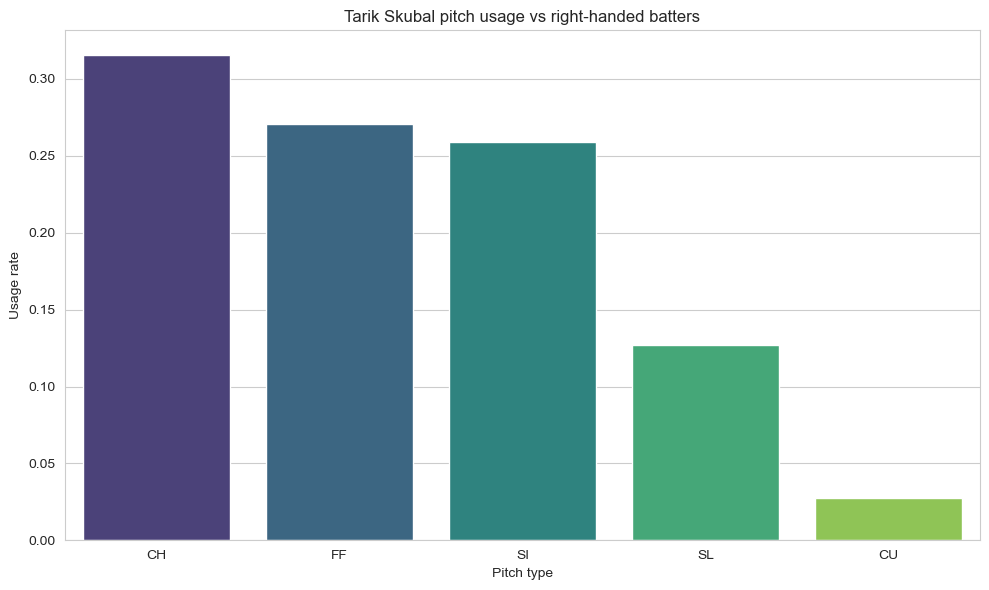


Skubal count-bucket pitch mix vs RHB:
     count_bucket pitch_type  pitches  usage_pct
3            even         SI       97   0.364662
2            even         FF       59   0.221805
0            even         CH       53   0.199248
4            even         SL       52   0.195489
1            even         CU        5   0.018797
7    hitter_ahead         SI       43   0.394495
5    hitter_ahead         CH       36   0.330275
6    hitter_ahead         FF       23   0.211009
8    hitter_ahead         SL        7   0.064220
9   pitcher_ahead         CH       39   0.333333
11  pitcher_ahead         FF       33   0.282051
12  pitcher_ahead         SI       28   0.239316
13  pitcher_ahead         SL       11   0.094017
10  pitcher_ahead         CU        6   0.051282
14     two_strike         CH      111   0.418868
16     two_strike         FF       90   0.339623
17     two_strike         SI       28   0.105660
18     two_strike         SL       26   0.098113
15     two_strike         CU  

<Figure size 1200x700 with 0 Axes>

<Axes: xlabel='count_bucket', ylabel='usage_pct'>

Text(0.5, 1.0, 'Tarik Skubal pitch mix by count bucket vs right-handed batters')

Text(0.5, 0, 'Count bucket')

Text(0, 0.5, 'Usage rate')

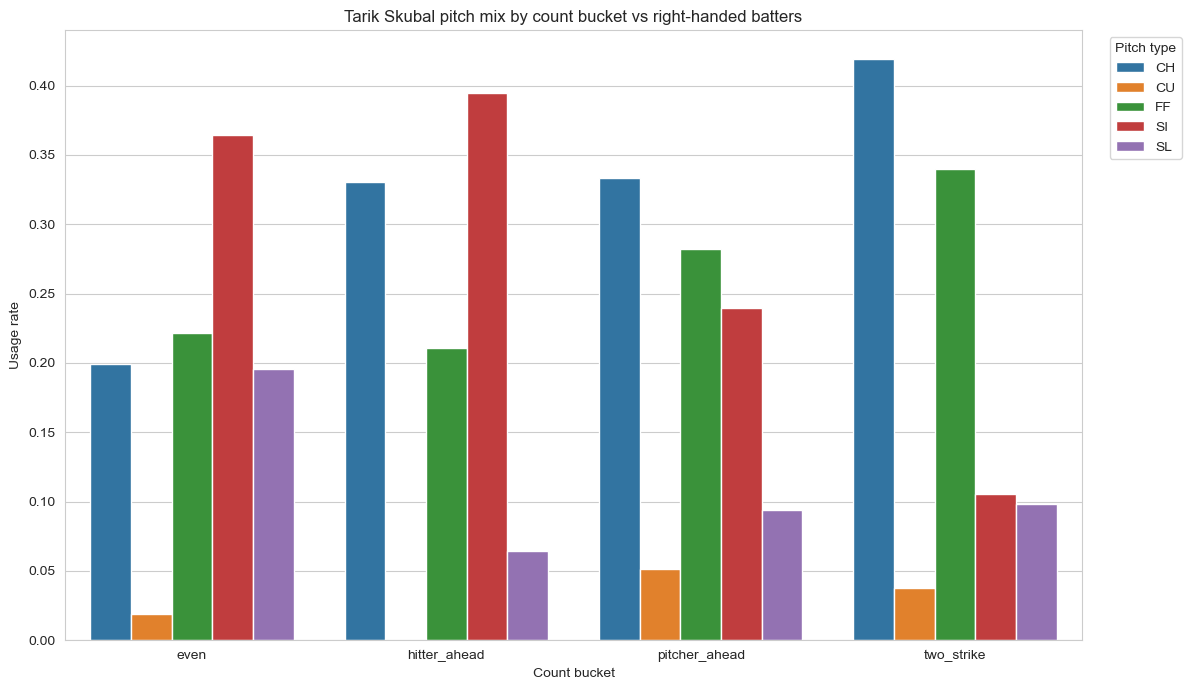

In [109]:
skubal_df = df[
    (df["player_name"] == skubal_name) &
    (df["stand"] == "R")
].copy()

print("\nSkubal vs RHB sample size:", skubal_df.shape[0])
print(skubal_df.head())

if skubal_df.shape[0] > 0:
    # Pitch usage overall
    skubal_pitch_usage = (
        skubal_df.groupby("pitch_type", dropna=False)
        .size()
        .reset_index(name="pitches")
        .sort_values("pitches", ascending=False)
    )
    skubal_pitch_usage["usage_pct"] = skubal_pitch_usage["pitches"] / skubal_pitch_usage["pitches"].sum()

    print("\nSkubal pitch usage vs RHB:")
    print(skubal_pitch_usage)

    skubal_pitch_usage.to_csv("week4_skubal_pitch_usage.csv", index=False)

    plt.figure(figsize=(10, 6))
sns.barplot(
    data=skubal_pitch_usage,
    x="pitch_type",
    y="usage_pct",
    hue="pitch_type",      # avoids seaborn palette warning
    palette="viridis",
    legend=False
)
plt.title("Tarik Skubal pitch usage vs right-handed batters")
plt.xlabel("Pitch type")
plt.ylabel("Usage rate")
plt.tight_layout()
plt.savefig("week4_skubal_pitch_usage_bar.png", dpi=300, bbox_inches="tight")
plt.show()

 # Count bucket summary
skubal_df["count_bucket"] = skubal_df.apply(classify_count_bucket, axis=1)

skubal_count_mix = (
    skubal_df.groupby(["count_bucket", "pitch_type"], dropna=False)
    .size()
    .reset_index(name="pitches")
    )

skubal_count_mix["usage_pct"] = (
    skubal_count_mix.groupby("count_bucket")["pitches"]
    .transform(lambda x: x / x.sum())
    )

print("\nSkubal count-bucket pitch mix vs RHB:")
print(skubal_count_mix.sort_values(["count_bucket", "usage_pct"], ascending=[True, False]))

skubal_count_mix.to_csv("week4_skubal_count_mix.csv", index=False)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=skubal_count_mix,
    x="count_bucket",
    y="usage_pct",
    hue="pitch_type"
)
plt.title("Tarik Skubal pitch mix by count bucket vs right-handed batters")
plt.xlabel("Count bucket")
plt.ylabel("Usage rate")
plt.legend(title="Pitch type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("week4_skubal_count_bucket_mix.png", dpi=300, bbox_inches="tight")
plt.show()

    # Top pitch types for location heatmaps
def plot_pitch_location_heatmaps(
    pitcher_df,
    pitch_types,
    title_prefix="Pitcher locations",
    min_pitches=10,
    save_path=None,
    dpi=300
):
    plot_df = pitcher_df.copy()
    plot_df = add_zone_bins(plot_df, n_bins=20)

    n = len(pitch_types)
    fig, axes = plt.subplots(1, n, figsize=(7 * n, 6))

    if n == 1:
        axes = [axes]

    for ax, pt in zip(axes, pitch_types):
        sub = plot_df[plot_df["pitch_type"] == pt].copy()

        if sub.shape[0] < min_pitches:
            ax.set_title(f"{pt}: not enough pitches")
            ax.axis("off")
            continue

        zone_counts = (
            sub.groupby(["z_bin", "x_bin"], observed=False)
            .size()
            .reset_index(name="pitch_count")
        )

        heatmap = zone_counts.pivot_table(
            index="z_bin",
            columns="x_bin",
            values="pitch_count",
            observed=False
        )
        heatmap = heatmap.iloc[::-1]

        sns.heatmap(
            heatmap,
            cmap="Reds",
            linewidths=0.3,
            cbar_kws={"label": "Pitch count"},
            ax=ax
        )
        ax.set_title(f"{title_prefix}: {pt}")
        ax.set_xlabel("Plate X bin")
        ax.set_ylabel("Plate Z bin")

    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"Saved: {save_path}")

    plt.show()



Skubal vs RHB sample size: 757
        game_date  game_pk  at_bat_number  pitch_number  batter  pitcher  \
16143  2025-06-24   777386             49             6  649966   669373   
16144  2025-06-24   777386             49             5  649966   669373   
16145  2025-06-24   777386             49             4  649966   669373   
16146  2025-06-24   777386             49             3  649966   669373   
16147  2025-06-24   777386             49             2  649966   669373   

         player_name pitch_type       pitch_name  release_speed  ...  \
16143  Skubal, Tarik         SL           Slider           90.9  ...   
16144  Skubal, Tarik         FF  4-Seam Fastball           97.6  ...   
16145  Skubal, Tarik         CH         Changeup           85.8  ...   
16146  Skubal, Tarik         CH         Changeup           89.3  ...   
16147  Skubal, Tarik         CH         Changeup           85.7  ...   

       is_whiff  is_called_strike  is_ball  is_in_play  made_contact  \
16143 

<Figure size 1000x600 with 0 Axes>

C:\Users\Newuser\AppData\Local\Temp\ipykernel_22364\1884125251.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=skubal_pitch_usage, x="pitch_type", y="usage_pct", palette="viridis")


<Axes: xlabel='pitch_type', ylabel='usage_pct'>

Text(0.5, 1.0, 'Tarik Skubal pitch usage vs right-handed batters')

Text(0.5, 0, 'Pitch type')

Text(0, 0.5, 'Usage rate')

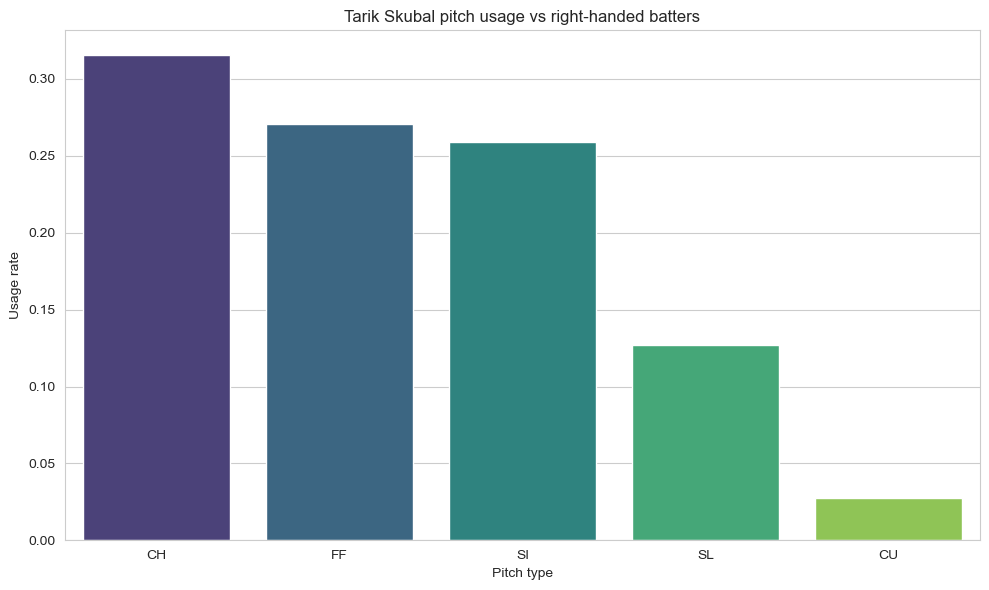


Skubal count-bucket pitch mix vs RHB:
     count_bucket pitch_type  pitches  usage_pct
3            even         SI       97   0.364662
2            even         FF       59   0.221805
0            even         CH       53   0.199248
4            even         SL       52   0.195489
1            even         CU        5   0.018797
7    hitter_ahead         SI       43   0.394495
5    hitter_ahead         CH       36   0.330275
6    hitter_ahead         FF       23   0.211009
8    hitter_ahead         SL        7   0.064220
9   pitcher_ahead         CH       39   0.333333
11  pitcher_ahead         FF       33   0.282051
12  pitcher_ahead         SI       28   0.239316
13  pitcher_ahead         SL       11   0.094017
10  pitcher_ahead         CU        6   0.051282
14     two_strike         CH      111   0.418868
16     two_strike         FF       90   0.339623
17     two_strike         SI       28   0.105660
18     two_strike         SL       26   0.098113
15     two_strike         CU  

<Figure size 1200x700 with 0 Axes>

<Axes: xlabel='count_bucket', ylabel='usage_pct'>

Text(0.5, 1.0, 'Tarik Skubal pitch mix by count bucket vs right-handed batters')

Text(0.5, 0, 'Count bucket')

Text(0, 0.5, 'Usage rate')

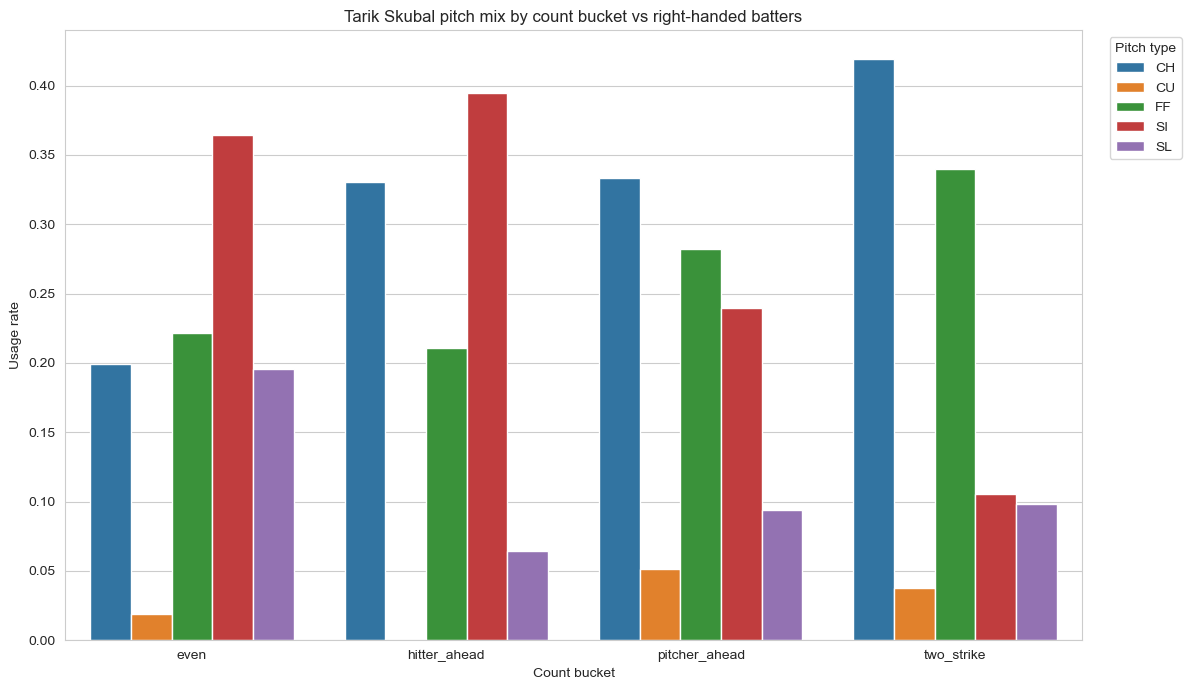


Top Skubal pitch types vs RHB: ['CH', 'FF', 'SI']


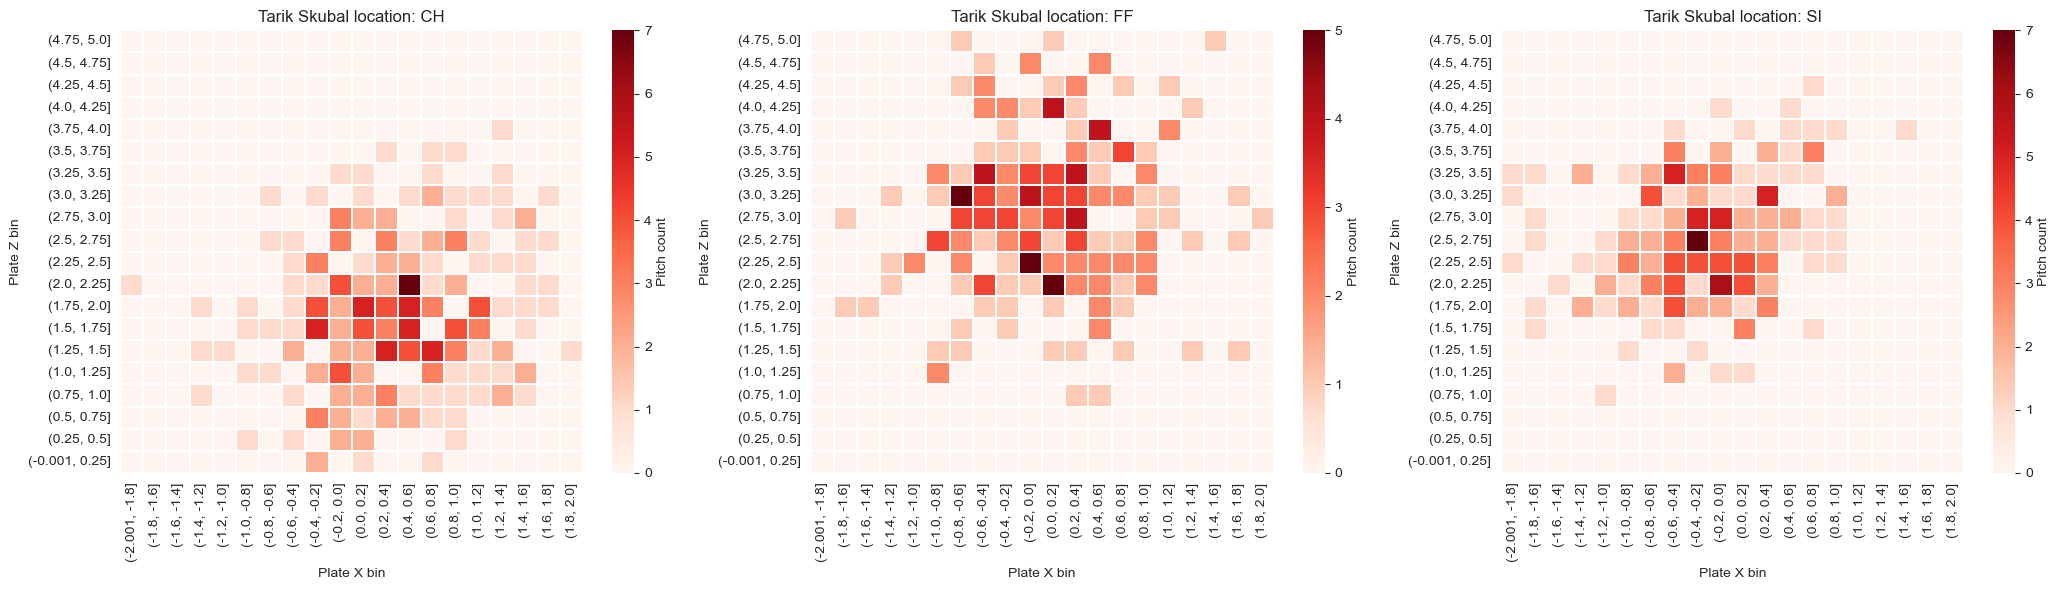

In [110]:
skubal_df = df[
    (df["player_name"] == skubal_name) &
    (df["stand"] == "R")
].copy()

print("\nSkubal vs RHB sample size:", skubal_df.shape[0])
print(skubal_df.head())

if skubal_df.shape[0] > 0:
    # Pitch usage overall
    skubal_pitch_usage = (
        skubal_df.groupby("pitch_type", dropna=False)
        .size()
        .reset_index(name="pitches")
        .sort_values("pitches", ascending=False)
    )
    skubal_pitch_usage["usage_pct"] = skubal_pitch_usage["pitches"] / skubal_pitch_usage["pitches"].sum()

    print("\nSkubal pitch usage vs RHB:")
    print(skubal_pitch_usage)

    skubal_pitch_usage.to_csv("week4_skubal_pitch_usage.csv", index=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=skubal_pitch_usage, x="pitch_type", y="usage_pct", palette="viridis")
    plt.title("Tarik Skubal pitch usage vs right-handed batters")
    plt.xlabel("Pitch type")
    plt.ylabel("Usage rate")
    plt.tight_layout()
    plt.show()

    # Count bucket summary
    skubal_df["count_bucket"] = skubal_df.apply(classify_count_bucket, axis=1)

    skubal_count_mix = (
        skubal_df.groupby(["count_bucket", "pitch_type"], dropna=False)
        .size()
        .reset_index(name="pitches")
    )

    skubal_count_mix["usage_pct"] = (
        skubal_count_mix.groupby("count_bucket")["pitches"]
        .transform(lambda x: x / x.sum())
    )

    print("\nSkubal count-bucket pitch mix vs RHB:")
    print(skubal_count_mix.sort_values(["count_bucket", "usage_pct"], ascending=[True, False]))

    skubal_count_mix.to_csv("week4_skubal_count_mix.csv", index=False)

    plt.figure(figsize=(12, 7))
    sns.barplot(
        data=skubal_count_mix,
        x="count_bucket",
        y="usage_pct",
        hue="pitch_type"
    )
    plt.title("Tarik Skubal pitch mix by count bucket vs right-handed batters")
    plt.xlabel("Count bucket")
    plt.ylabel("Usage rate")
    plt.legend(title="Pitch type", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    # Top pitch types for location heatmaps
    top_pitch_types = skubal_pitch_usage["pitch_type"].head(3).tolist()
    print("\nTop Skubal pitch types vs RHB:", top_pitch_types)

    plot_pitch_location_heatmaps(
        skubal_df,
        pitch_types=top_pitch_types,
        title_prefix="Tarik Skubal location",
        min_pitches=10
    )

else:
    print("\nNo Skubal vs RHB rows found. Check the exact player name.")


Saved: week4_skubal_location_heatmaps_CH_FF_SI.png


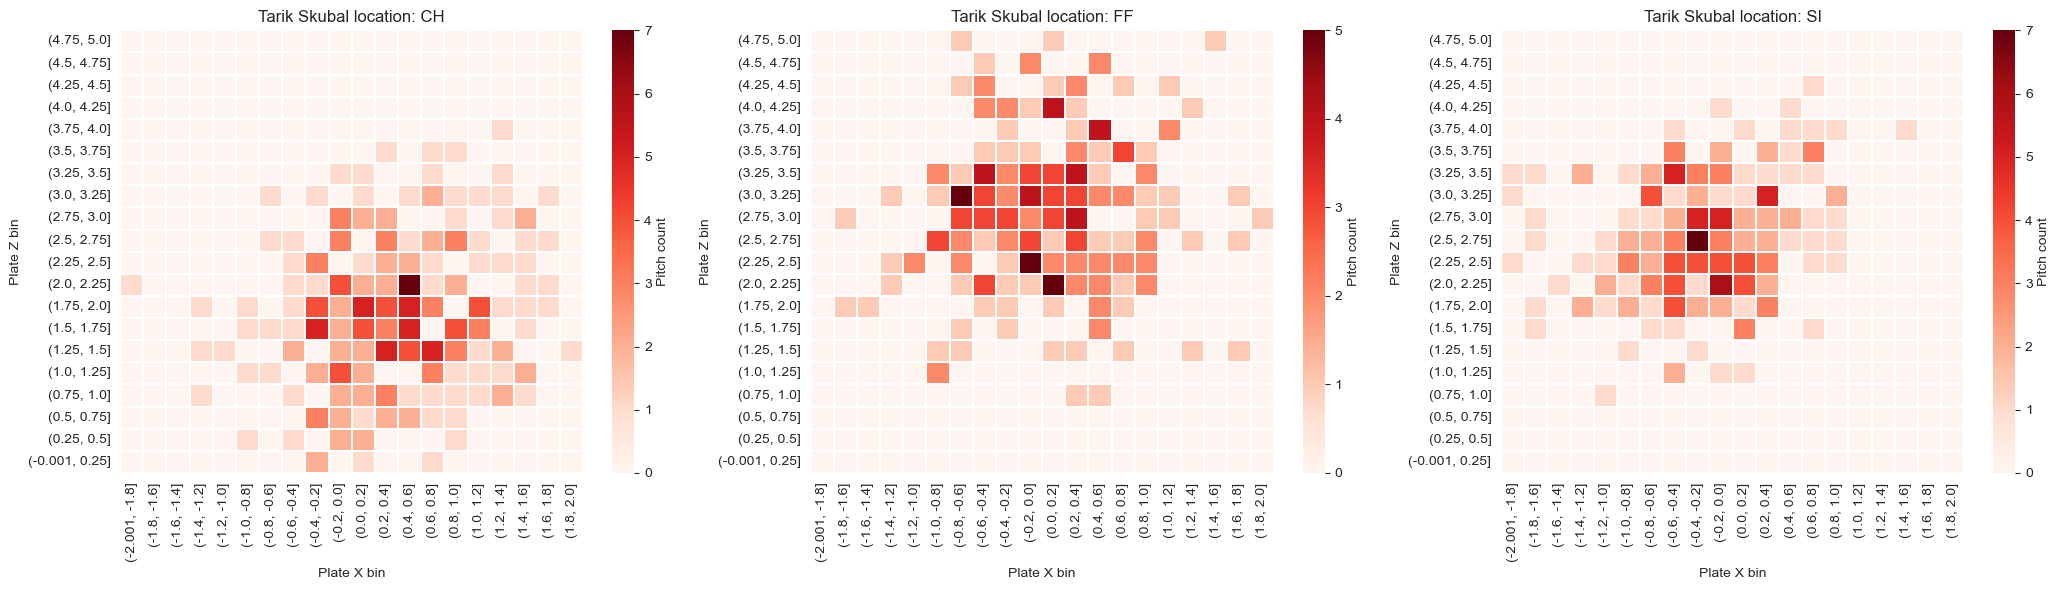

In [111]:
top_pitch_types = skubal_pitch_usage["pitch_type"].head(3).tolist()

plot_pitch_location_heatmaps(
    skubal_df,
    pitch_types=top_pitch_types,
    title_prefix="Tarik Skubal location",
    min_pitches=10,
    save_path="week4_skubal_location_heatmaps_CH_FF_SI.png"
)

In [112]:
  # Skubal pitch usage
if skubal_df.shape[0] > 0:
    skubal_pitch_usage_small = skubal_pitch_usage[["pitch_type", "pitches", "usage_pct"]].copy()

    matchup_pitch_table = skubal_pitch_usage_small.sort_values("usage_pct", ascending=False)

    print("\nMatchup pitch table:")
    print(matchup_pitch_table)

    matchup_pitch_table.to_csv("week4_batter_skubal_matchup_pitch_table.csv", index=False)

print("\nWeek 4 starter outputs saved.")


Matchup pitch table:
  pitch_type  pitches  usage_pct
0         CH      239   0.315720
2         FF      205   0.270806
3         SI      196   0.258917
4         SL       96   0.126816
1         CU       21   0.027741

Week 4 starter outputs saved.
